In [17]:
from torchvision.datasets import VOCDetection
import torchvision.transforms as T
import torch
import timm
import torch.nn as nn
import torch.nn.functional as F
from torchvision import ops
from torchvision.ops import box_iou
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [18]:
transform = T.Compose([
    T.Resize((416, 416)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = VOCDetection(
    root="voc",
    year="2007",
    image_set="train",   
    download=True,
    transform=transform
)

test_dataset = VOCDetection(
    root="voc",
    year="2007",
    image_set="val",    
    download=True,
    transform=transform
)

In [19]:
VOC_CLASSES = [
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow",
    "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor"
]

NUM_CLASSES = len(VOC_CLASSES)
NUM_ANCHORS = 3
NUM_OUTPUTS = 5 + NUM_CLASSES

anchors = [
    (10, 13), (16, 30), (33, 23),
    (30, 61), (62, 45), (59, 119),
    (116, 90), (156, 198), (373, 326)
]
grid_sizes = [416 // 8, 416 // 16, 416 // 32]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [20]:
backbone = timm.create_model("darknet53", pretrained=True, features_only=True)

for param in backbone.parameters():
    param.requires_grad = False

backbone = backbone.to(DEVICE).eval()
print(backbone.feature_info.channels())

[32, 64, 128, 256, 512, 1024]


In [21]:
head_large_feat = nn.Sequential(
    nn.Conv2d(1024, 512, 1, 1, 0, bias=False), nn.BatchNorm2d(512), nn.LeakyReLU(0.1, inplace=True),
    nn.Conv2d(512, 1024, 3, 1, 1, bias=False), nn.BatchNorm2d(1024), nn.LeakyReLU(0.1, inplace=True),
    nn.Conv2d(1024, 512, 1, 1, 0, bias=False), nn.BatchNorm2d(512), nn.LeakyReLU(0.1, inplace=True),
    nn.Conv2d(512, 1024, 3, 1, 1, bias=False), nn.BatchNorm2d(1024), nn.LeakyReLU(0.1, inplace=True),
    nn.Conv2d(1024, 512, 1, 1, 0, bias=False), nn.BatchNorm2d(512), nn.LeakyReLU(0.1, inplace=True),
)
head_large_pred = nn.Conv2d(512, NUM_ANCHORS * NUM_OUTPUTS, 1, 1, 0, bias=True)

upsample_1 = nn.Sequential(
    nn.Conv2d(512, 256, 1, 1, 0, bias=False), nn.BatchNorm2d(256), nn.LeakyReLU(0.1, inplace=True),
    nn.Upsample(scale_factor=2, mode='nearest')
)
route_conv_1 = nn.Sequential(
    nn.Conv2d(512, 256, 1, 1, 0, bias=False), nn.BatchNorm2d(256), nn.LeakyReLU(0.1, inplace=True)
)

head_medium_feat = nn.Sequential(
    nn.Conv2d(512, 256, 1, 1, 0, bias=False), nn.BatchNorm2d(256), nn.LeakyReLU(0.1, inplace=True),
    nn.Conv2d(256, 512, 3, 1, 1, bias=False), nn.BatchNorm2d(512), nn.LeakyReLU(0.1, inplace=True),
    nn.Conv2d(512, 256, 1, 1, 0, bias=False), nn.BatchNorm2d(256), nn.LeakyReLU(0.1, inplace=True),
    nn.Conv2d(256, 512, 3, 1, 1, bias=False), nn.BatchNorm2d(512), nn.LeakyReLU(0.1, inplace=True),
    nn.Conv2d(512, 256, 1, 1, 0, bias=False), nn.BatchNorm2d(256), nn.LeakyReLU(0.1, inplace=True),
)
head_medium_pred = nn.Conv2d(256, NUM_ANCHORS * NUM_OUTPUTS, 1, 1, 0, bias=True)

upsample_2 = nn.Sequential(
    nn.Conv2d(256, 128, 1, 1, 0, bias=False), nn.BatchNorm2d(128), nn.LeakyReLU(0.1, inplace=True),
    nn.Upsample(scale_factor=2, mode='nearest')
)
route_conv_2 = nn.Sequential(
    nn.Conv2d(256, 128, 1, 1, 0, bias=False), nn.BatchNorm2d(128), nn.LeakyReLU(0.1, inplace=True)
)

head_small_feat = nn.Sequential(
    nn.Conv2d(256, 128, 1, 1, 0, bias=False), nn.BatchNorm2d(128), nn.LeakyReLU(0.1, inplace=True),
    nn.Conv2d(128, 256, 3, 1, 1, bias=False), nn.BatchNorm2d(256), nn.LeakyReLU(0.1, inplace=True),
    nn.Conv2d(256, 128, 1, 1, 0, bias=False), nn.BatchNorm2d(128), nn.LeakyReLU(0.1, inplace=True),
    nn.Conv2d(128, 256, 3, 1, 1, bias=False), nn.BatchNorm2d(256), nn.LeakyReLU(0.1, inplace=True),
    nn.Conv2d(256, 128, 1, 1, 0, bias=False), nn.BatchNorm2d(128), nn.LeakyReLU(0.1, inplace=True),
)
head_small_pred = nn.Conv2d(128, NUM_ANCHORS * NUM_OUTPUTS, 1, 1, 0, bias=True)

In [22]:
head_modules = [
    head_large_feat, head_large_pred, upsample_1, route_conv_1,
    head_medium_feat, head_medium_pred, upsample_2, route_conv_2,
    head_small_feat, head_small_pred
]
for m in head_modules:
    m.to(DEVICE)

In [23]:
def _reshape_raw(raw, num_anchors, num_outputs, grid):
    raw = raw.view(-1, num_anchors, num_outputs, grid, grid)
    return raw.permute(0, 1, 3, 4, 2).contiguous()

def decode_pred(raw, anchors):
    anchors = anchors.reshape(1, -1, 1, 1, 2)
    obj = torch.sigmoid(raw[..., 0:1])           
    xy = torch.sigmoid(raw[..., 1:3])          
    wh = torch.exp(raw[..., 3:5].clamp(max=10)) * anchors  
    cls = torch.sigmoid(raw[..., 5:])            

    return torch.cat([obj, xy, wh, cls], dim=-1)

def forward(x):
    with torch.no_grad():
        features = backbone(x)

    c3, c4, c5 = features[3], features[4], features[5]

    x1 = head_large_feat(c5)
    raw_large = _reshape_raw(head_large_pred(x1), NUM_ANCHORS, NUM_OUTPUTS, 13)

    x1_up = upsample_1(x1)
    c4_r = route_conv_1(c4)
    x2 = head_medium_feat(torch.cat([x1_up, c4_r], dim=1))
    raw_medium = _reshape_raw(head_medium_pred(x2), NUM_ANCHORS, NUM_OUTPUTS, 26)

    x2_up = upsample_2(x2)
    c3_r = route_conv_2(c3)
    x3 = head_small_feat(torch.cat([x2_up, c3_r], dim=1))
    raw_small = _reshape_raw(head_small_pred(x3), NUM_ANCHORS, NUM_OUTPUTS, 52)

    return raw_small, raw_medium, raw_large

In [24]:
lambda_box = 5
lambda_obj = 1
lambda_noobj = 0.5
lambda_class = 1

def _single_scale(predictions, target, anchors, num_classes):
    pred = predictions.clone()
    tgt  = target.clone()

    obj_mask   = tgt[..., 0] == 1
    noobj_mask = tgt[..., 0] == 0

    noobj_loss = F.binary_cross_entropy_with_logits(
        pred[..., 0][noobj_mask],
        tgt[..., 0][noobj_mask],
        reduction='mean'
    )

    if obj_mask.sum() > 0:
        obj_loss = F.binary_cross_entropy_with_logits(
            pred[..., 0][obj_mask],
            torch.ones_like(pred[..., 0][obj_mask]),
            reduction='mean'
        )
    else:
        obj_loss = torch.tensor(0.0, device=pred.device)

    if obj_mask.sum() > 0:
        pred_boxes = pred[..., 1:5][obj_mask].clone()
        tgt_boxes  = tgt[..., 1:5][obj_mask].clone()

        pred_boxes[..., 0:2] = torch.sigmoid(pred_boxes[..., 0:2])

        anchor_wh = anchors.reshape(1, -1, 1, 1, 2)  
        anchor_wh_exp = anchor_wh.expand(pred.shape[0], -1, pred.shape[2], pred.shape[3], 2)
        anchor_obj = anchor_wh_exp[obj_mask]         

        tgt_boxes[..., 2:4] = torch.log(
            tgt_boxes[..., 2:4] / (anchor_obj + 1e-16)
        )

        box_loss = F.mse_loss(pred_boxes, tgt_boxes, reduction='mean')
    else:
        box_loss = torch.tensor(0.0, device=pred.device)

    if obj_mask.sum() > 0:
        class_target = torch.zeros(
            (obj_mask.sum(), num_classes), device=pred.device
        )
        class_indices = tgt[..., 5][obj_mask].long()
        class_target[torch.arange(len(class_indices)), class_indices] = 1.0

        class_loss = F.binary_cross_entropy_with_logits(
            pred[..., 5:][obj_mask],
            class_target,
            reduction='mean'
        )
    else:
        class_loss = torch.tensor(0.0, device=pred.device)

    total = (lambda_box * box_loss +
             lambda_obj * obj_loss +
             lambda_noobj * noobj_loss +
             lambda_class * class_loss)

    return total


def yolo_loss(pred_small, pred_medium, pred_large,
              target_small, target_medium, target_large,
              anchors_small, anchors_medium, anchors_large,
              num_classes=NUM_CLASSES):
    loss_small  = _single_scale(pred_small,  target_small,  anchors_small,  num_classes)
    loss_medium = _single_scale(pred_medium, target_medium, anchors_medium, num_classes)
    loss_large  = _single_scale(pred_large,  target_large,  anchors_large,  num_classes)

    total_loss = loss_small + loss_medium + loss_large
    return total_loss, loss_small, loss_medium, loss_large

In [ ]:
def parse_annotations(target, img_size=416):
    ann = target["annotation"]
    orig_width = int(ann["size"]["width"])
    orig_height = int(ann["size"]["height"])

    scale_x = img_size / orig_width
    scale_y = img_size / orig_height

    objects = ann.get("object", [])
    if isinstance(objects, dict):   
        objects = [objects]

    parsed = []
    for obj in objects:
        name = obj["name"]
        if name not in VOC_CLASSES:
            continue

        box = obj["bndbox"]
        x_min = float(box["xmin"]) * scale_x
        y_min = float(box["ymin"]) * scale_y
        x_max = float(box["xmax"]) * scale_x
        y_max = float(box["ymax"]) * scale_y

        w = x_max - x_min
        h = y_max - y_min
        if w <= 0 or h <= 0:
            continue

        parsed.append({
            "bbox": [x_min, y_min, w, h],
            "class_idx": VOC_CLASSES.index(name),
        })

    return parsed


def iou_wh(wh1, wh2):
    wh1 = wh1.reshape(-1, 2)
    wh2 = wh2.reshape(-1, 2)

    boxes1 = torch.cat([torch.zeros_like(wh1), wh1], dim=1)
    boxes2 = torch.cat([torch.zeros_like(wh2), wh2], dim=1)

    return box_iou(boxes1, boxes2)


def build_targets(annotations, img_size=416, grid_sizes=grid_sizes, anchors=anchors,
                   num_anchors_per_scale=3, num_classes=NUM_CLASSES, ignore_iou_thresh=0.5):
    targets = [
        torch.zeros((num_anchors_per_scale, grid_sizes[i], grid_sizes[i], 5 + num_classes))
        for i in range(3)
    ]

    anchors_wh = torch.tensor([[aw / img_size, ah / img_size] for aw, ah in anchors])

    for ann in annotations:
        x_min, y_min, w, h = ann["bbox"]
        class_idx = ann["class_idx"]

        x_center = (x_min + w / 2) / img_size
        y_center = (y_min + h / 2) / img_size
        w_norm = w / img_size
        h_norm = h / img_size

        if w_norm <= 0 or h_norm <= 0:
            continue

        box_wh = torch.tensor([[w_norm, h_norm]])
        iou_anchors = iou_wh(box_wh, anchors_wh).squeeze(0)
        anchor_indices = iou_anchors.argsort(descending=True)

        assigned = False                   

        for anchor_idx in anchor_indices:
            scale_idx = anchor_idx // num_anchors_per_scale
            anchor_on_scale = anchor_idx % num_anchors_per_scale

            grid_size = grid_sizes[scale_idx]
            i = int(y_center * grid_size)
            j = int(x_center * grid_size)
            i = min(i, grid_size - 1)
            j = min(j, grid_size - 1)

            anchor_taken = targets[scale_idx][anchor_on_scale, i, j, 0]

            if not anchor_taken and not assigned:
                targets[scale_idx][anchor_on_scale, i, j, 0] = 1

                x_cell = x_center * grid_size - j
                y_cell = y_center * grid_size - i
                w_cell = w_norm * grid_size
                h_cell = h_norm * grid_size

                targets[scale_idx][anchor_on_scale, i, j, 1:5] = torch.tensor(
                    [x_cell, y_cell, w_cell, h_cell]
                )
                targets[scale_idx][anchor_on_scale, i, j, 5] = class_idx
                assigned = True

            elif not anchor_taken and iou_anchors[anchor_idx] > ignore_iou_thresh:
                targets[scale_idx][anchor_on_scale, i, j, 0] = -1

    return targets[0], targets[1], targets[2]

In [26]:
strides = [32, 16, 8]

anchors_tensor = torch.tensor(anchors, dtype=torch.float32).reshape(3, 3, 2)
anchors_small  = (anchors_tensor[0] / 8).to(DEVICE)
anchors_medium = (anchors_tensor[1] / 16).to(DEVICE)
anchors_large  = (anchors_tensor[2] / 32).to(DEVICE)


def collate_fn(batch):
    images, targets_small, targets_medium, targets_large = [], [], [], []

    for img, target in batch:
        parsed = parse_annotations(target, img_size=416)
        t_small, t_medium, t_large = build_targets(parsed)

        images.append(img)
        targets_small.append(t_small)
        targets_medium.append(t_medium)
        targets_large.append(t_large)

    images = torch.stack(images)
    targets_small = torch.stack(targets_small)
    targets_medium = torch.stack(targets_medium)
    targets_large = torch.stack(targets_large)

    return images, targets_small, targets_medium, targets_large

def train(num_epochs=10, batch_size=4, lr=1e-4, warmup_epochs=1, scheduler_type="cosine"):
    params = []
    for m in head_modules:
        params += list(m.parameters())
    optimizer = torch.optim.Adam(params, lr=lr)

    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True,
        collate_fn=collate_fn
    )

    steps_per_epoch = len(train_loader)
    total_steps = num_epochs * steps_per_epoch
    warmup_steps = warmup_epochs * steps_per_epoch

    if scheduler_type == "cosine":
        main_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=total_steps - warmup_steps, eta_min=lr * 0.01
        )
    elif scheduler_type == "step":
        main_scheduler = torch.optim.lr_scheduler.StepLR(
            optimizer, step_size=3 * steps_per_epoch, gamma=0.1
        )
    else:
        raise ValueError(f"Unknown scheduler_type: {scheduler_type}")

    global_step = 0

    print("Training...")
    for epoch in range(num_epochs):
        for m in head_modules:
            m.train()

        epoch_loss = 0.0

        for batch_idx, (images, target_small, target_medium, target_large) in enumerate(train_loader):
            images = images.to(DEVICE)
            target_small = target_small.to(DEVICE)
            target_medium = target_medium.to(DEVICE)
            target_large = target_large.to(DEVICE)

            raw_small, raw_medium, raw_large = forward(images)

            total_loss, loss_small, loss_medium, loss_large = yolo_loss(
                raw_small, raw_medium, raw_large,
                target_small, target_medium, target_large,
                anchors_small, anchors_medium, anchors_large,
            )

            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()

            if global_step < warmup_steps:
                warmup_lr = lr * (global_step + 1) / warmup_steps
                for pg in optimizer.param_groups:
                    pg["lr"] = warmup_lr
            else:
                main_scheduler.step()

            global_step += 1
            epoch_loss += total_loss.item()

            if batch_idx % 50 == 0:
                current_lr = optimizer.param_groups[0]["lr"]
                print(
                    f"Epoch {epoch+1} | Batch {batch_idx} | lr: {current_lr:.2e} | "
                    f"total: {total_loss.item():.3f} "
                    f"(s: {loss_small.item():.3f}, m: {loss_medium.item():.3f}, l: {loss_large.item():.3f})"
                )

        print(f"=== Epoch {epoch+1} done | avg loss: {epoch_loss / len(train_loader):.3f} ===")

In [27]:
train(num_epochs=25, batch_size=16, lr=1e-4)

Training...
Epoch 1 | Batch 0 | lr: 6.37e-07 | total: 10.556 (s: 2.909, m: 2.959, l: 4.687)
Epoch 1 | Batch 50 | lr: 3.25e-05 | total: 7.920 (s: 2.886, m: 2.437, l: 2.596)
Epoch 1 | Batch 100 | lr: 6.43e-05 | total: 6.444 (s: 2.191, m: 2.245, l: 2.008)
Epoch 1 | Batch 150 | lr: 9.62e-05 | total: 5.455 (s: 1.821, m: 1.900, l: 1.733)
=== Epoch 1 done | avg loss: 7.187 ===
Epoch 2 | Batch 0 | lr: 1.00e-04 | total: 3.736 (s: 0.411, m: 1.767, l: 1.557)
Epoch 2 | Batch 50 | lr: 1.00e-04 | total: 4.903 (s: 1.850, m: 1.690, l: 1.363)
Epoch 2 | Batch 100 | lr: 9.98e-05 | total: 4.190 (s: 1.264, m: 1.492, l: 1.434)
Epoch 2 | Batch 150 | lr: 9.96e-05 | total: 4.244 (s: 1.663, m: 1.298, l: 1.282)
=== Epoch 2 done | avg loss: 4.514 ===
Epoch 3 | Batch 0 | lr: 9.96e-05 | total: 3.386 (s: 0.858, m: 1.259, l: 1.269)
Epoch 3 | Batch 50 | lr: 9.93e-05 | total: 3.455 (s: 1.007, m: 1.264, l: 1.184)
Epoch 3 | Batch 100 | lr: 9.89e-05 | total: 3.201 (s: 1.154, m: 0.954, l: 1.093)
Epoch 3 | Batch 150 | lr: 9

In [28]:
def predict(image_tensor, conf_thresh=0.5, nms_thresh=0.45):
    for m in head_modules:
        m.eval()

    x = image_tensor.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        raw_small, raw_medium, raw_large = forward(x)

        dec_small = decode_pred(raw_small, anchors_small)
        dec_medium = decode_pred(raw_medium, anchors_medium)
        dec_large = decode_pred(raw_large, anchors_large)

    all_boxes, all_scores, all_classes = [], [], []

    for dec, grid_size, stride in [
        (dec_small, 52, 8), (dec_medium, 26, 16), (dec_large, 13, 32)
    ]:
        dec = dec[0]
        A, G, _, O = dec.shape

        grid_y, grid_x = torch.meshgrid(
            torch.arange(G, device=DEVICE), torch.arange(G, device=DEVICE), indexing="ij"
        )
        grid_x = grid_x.reshape(1, G, G).expand(A, G, G)
        grid_y = grid_y.reshape(1, G, G).expand(A, G, G)

        obj_conf = dec[..., 0]
        class_probs = dec[..., 5:]
        class_conf, class_idx = class_probs.max(dim=-1)

        scores = obj_conf * class_conf

        mask = scores > conf_thresh
        if mask.sum() == 0:
            continue

        x_cell = dec[..., 1][mask]
        y_cell = dec[..., 2][mask]
        w_cell = dec[..., 3][mask]
        h_cell = dec[..., 4][mask]

        gx = grid_x[mask]
        gy = grid_y[mask]

        x_center = (gx + x_cell) * stride
        y_center = (gy + y_cell) * stride
        w = w_cell * stride
        h = h_cell * stride

        x1 = x_center - w / 2
        y1 = y_center - h / 2
        x2 = x_center + w / 2
        y2 = y_center + h / 2

        boxes = torch.stack([x1, y1, x2, y2], dim=-1)

        all_boxes.append(boxes)
        all_scores.append(scores[mask])
        all_classes.append(class_idx[mask])

    if len(all_boxes) == 0:
        return []

    all_boxes = torch.cat(all_boxes, dim=0)
    all_scores = torch.cat(all_scores, dim=0)
    all_classes = torch.cat(all_classes, dim=0)

    keep = ops.batched_nms(all_boxes, all_scores, all_classes, nms_thresh)

    results = []
    for idx in keep:
        results.append({
            "box": all_boxes[idx].cpu().tolist(),
            "conf": all_scores[idx].item(),
            "class_idx": all_classes[idx].item(),
        })

    return results


def visualize_prediction(image_tensor, predictions, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    img = image_tensor.clone().cpu()
    mean_t = torch.tensor(mean).reshape(3, 1, 1)
    std_t = torch.tensor(std).reshape(3, 1, 1)
    img = img * std_t + mean_t
    img = img.clamp(0, 1).permute(1, 2, 0).numpy()

    fig, ax = plt.subplots(1, figsize=(8, 8))
    ax.imshow(img)

    colors = plt.cm.hsv(torch.linspace(0, 1, NUM_CLASSES)).tolist()

    if len(predictions) == 0:
        ax.set_title("No detections above threshold")

    for pred in predictions:
        x1, y1, x2, y2 = pred["box"]
        cls_idx = pred["class_idx"]
        conf = pred["conf"]
        label = f"{VOC_CLASSES[cls_idx]} {conf:.2f}"

        w, h = x2 - x1, y2 - y1
        rect = patches.Rectangle(
            (x1, y1), w, h, linewidth=2,
            edgecolor=colors[cls_idx], facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(
            x1, max(y1 - 5, 0), label,
            color="white", fontsize=9,
            bbox=dict(facecolor=colors[cls_idx], alpha=0.7, pad=1, edgecolor="none")
        )

    ax.axis("off")
    plt.show()

2 detections


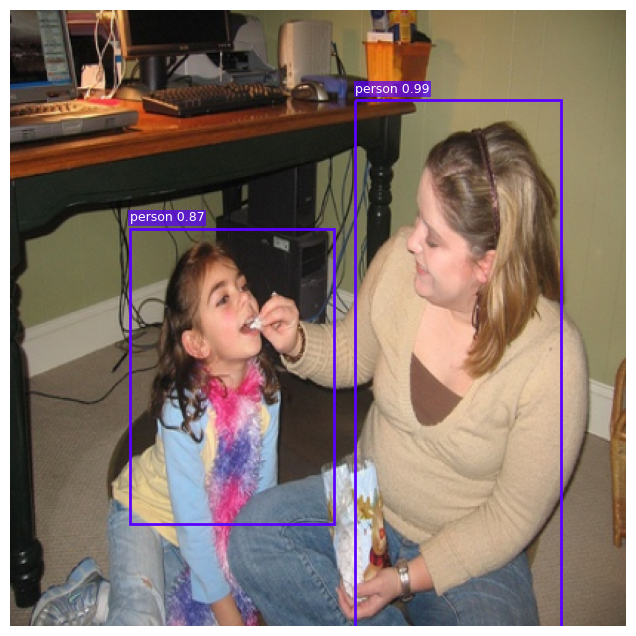

In [78]:
img, _ = test_dataset[70]
preds = predict(img, conf_thresh=0.65, nms_thresh=0.05)  
print(f"{len(preds)} detections")
visualize_prediction(img, preds)

In [30]:
checkpoint = {
        "head_large_feat": head_large_feat.state_dict(),
        "head_large_pred": head_large_pred.state_dict(),
        "upsample_1": upsample_1.state_dict(),
        "route_conv_1": route_conv_1.state_dict(),
        "head_medium_feat": head_medium_feat.state_dict(),
        "head_medium_pred": head_medium_pred.state_dict(),
        "upsample_2": upsample_2.state_dict(),
        "route_conv_2": route_conv_2.state_dict(),
        "head_small_feat": head_small_feat.state_dict(),
        "head_small_pred": head_small_pred.state_dict(),
    }

torch.save(checkpoint, "yolov3.pt")